<a href="https://colab.research.google.com/github/comparativechrono/Comparative-birthograms-reveal-country-specific-rephasing-of-human-birth-seasonality/blob/main/Chow_photoperiod_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

France breakpoint: 1995-07-01


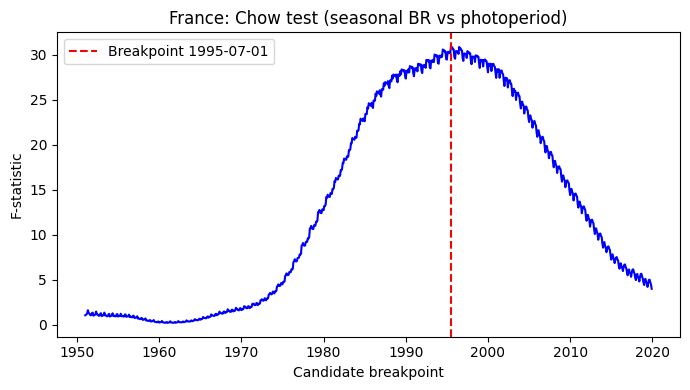

Germany breakpoint: 2012-06-01


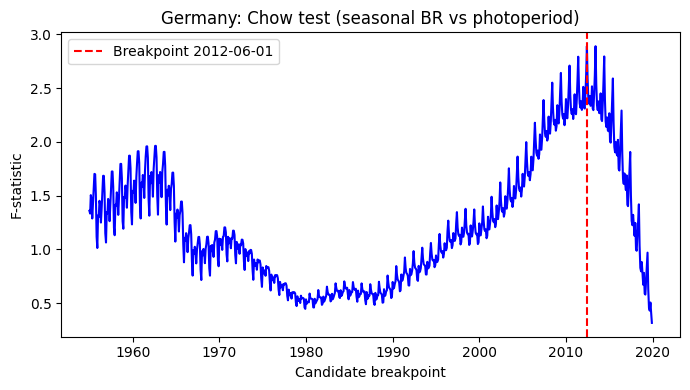

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from scipy.stats import f

MONTH_MAP = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

def chow_test_br_phot(csv_file, country_name):
    df = pd.read_csv(csv_file, header=None, names=['Year','Month','Births','Photoperiod'])
    df['Month_num'] = df['Month'].map(MONTH_MAP)
    df['Date'] = pd.to_datetime(
        df['Year'].astype(str) + '-' +
        df['Month_num'].astype(str).str.zfill(2) + '-01'
    )
    df = df.sort_values('Date').set_index('Date')

    # seasonal components
    br_seasonal  = STL(df['Births'].astype(float), period=12, robust=True).fit().seasonal
    phot_seasonal= STL(df['Photoperiod'].astype(float), period=12, robust=True).fit().seasonal
    dfs = pd.DataFrame({'BR': br_seasonal, 'phot': phot_seasonal}).dropna()

    y = dfs['BR']
    X = sm.add_constant(dfs[['phot']])
    full_model = sm.OLS(y, X).fit()
    rss_full = (full_model.resid**2).sum()
    n = len(y)
    k = X.shape[1]  # intercept + photoperiod

    # candidate breakpoints (exclude first/last 5 years)
    start_date = dfs.index.min() + pd.DateOffset(years=5)
    end_date   = dfs.index.max() - pd.DateOffset(years=5)
    scan_dates = pd.date_range(start_date, end_date, freq='MS')

    F_vals, p_vals = [], []
    for dt in scan_dates:
        pre_mask  = dfs.index <= dt
        post_mask = dfs.index > dt
        if pre_mask.sum() <= k or post_mask.sum() <= k:
            F_vals.append(np.nan)
            p_vals.append(np.nan)
            continue
        res_pre  = sm.OLS(y[pre_mask], X.loc[pre_mask]).fit().resid
        res_post = sm.OLS(y[post_mask],X.loc[post_mask]).fit().resid
        rss_split = (res_pre**2).sum() + (res_post**2).sum()
        F_stat = ((rss_full - rss_split)/k) / (rss_split/(n - 2*k))
        F_vals.append(F_stat)
        p_vals.append(1 - f.cdf(F_stat, k, n - 2*k))

    chow_df = pd.DataFrame({'F': F_vals, 'p': p_vals}, index=scan_dates)
    breakpoint = chow_df['F'].idxmax()
    print(f'{country_name} breakpoint: {breakpoint.date()}')

    # plot
    plt.figure(figsize=(7,4))
    plt.plot(chow_df.index, chow_df['F'], color='blue')
    plt.axvline(breakpoint, color='red', linestyle='--', label=f'Breakpoint {breakpoint.date()}')
    plt.title(f'{country_name}: Chow test (seasonal BR vs photoperiod)')
    plt.xlabel('Candidate breakpoint')
    plt.ylabel('F-statistic')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return chow_df, breakpoint

# Run for France and Germany
chow_france, break_france = chow_test_br_phot('french_photoperiod_data.csv', 'France')
chow_germany, break_germany = chow_test_br_phot('german_photoperiod_data.csv', 'Germany')